In [1]:
import Pkg
Pkg.activate("../chebcoefs")
Pkg.instantiate()

  Activating project at `~/repos/WaveGreen2D/chebcoefs`


In [2]:
using CairoMakie
using FastChebInterp
using QuadGK
using StaticArrays

In [3]:
# Tolerance is set by default to machine precision, but can be adjusted to the desired value.
# For a well chosen quadrature order, the maximum number of function evaluations does not go beyond 10³.
# For L₁ and L₂, especially close to the poles, the best quadrature order is between 24 and 34.
tol = eps()
imax = 1e3
qorder = 26


function mod_quadgk(f, a, b; rtol=sqrt(eps()), atol=0, maxevals=10^7, order=7)
    # Put 26 as the first try.
    qorder_vals = [[26, 25, 24]; collect(27:34)]
    
    if !(order in qorder_vals)
        pushfirst!(qorder_vals, order)
    end

    ∫f = err = nothing
    
    for qo in qorder_vals
        ∫f, err, count = quadgk_count(f, a, b; rtol=rtol, atol=atol, maxevals=maxevals, order=qo)
        if count < maxevals
            return ∫f, err
        end
    end

    @warn "Reached the maximum number of function evaluations" #maxlog=1
    
    return ∫f, err
end


function L₁H(x::AbstractVector{<:Real})
    A, B, H = x
    
    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = exp(-u*(2+B)) + exp(-u*(2-B))
    h(u) = cos(u*A)
    p(u) = (f(u) * g(u) * h(u) + exp(-u)) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(p, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(p, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function L₂H(x::AbstractVector{<:Real})
    A, B, H = x

    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = (u + H)^2 / ((u - H)^2 - (u^2 - H^2)*exp(-2u))
    p(u) = exp(-u*(2+B))
    q(u) = exp(-u*(4-B))
    r(u) = cos(u*A)
    
    h(u) = (f(u)*p(u) + g(u)*q(u)) * r(u) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    
    y  = mod_quadgk(h, path[1], path[2]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[2], path[3]; rtol=tol, atol=tol, maxevals=imax, order=qorder)[1]
    y += mod_quadgk(h, path[3], path[4]; rtol=tol, atol=tol, maxevals=imax)[1]
    
    return real(y)
end


function L₁C(x::AbstractVector{<:Real})
    A, B, C = x  # C = ln(H)
    x̄ = [A, B, exp(C)]
    return L₁H(x̄)
end


function L₂C(x::AbstractVector{<:Real})
    A, B, C = x  # C = ln(H)
    x̄ = [A, B, exp(C)]
    return L₂H(x̄)
end


function generate_coefficients(L, n, lb, ub; tol=eps())
    x = chebpoints(n, lb, ub)
    c = chebinterp(L.(x), lb, ub; tol=tol)
    return c.coefs
end;

In [4]:
Hmin = 1e-2
Hmed = 1.64
Hmax = π  # H > π is the infinite depth case
Hmax2 = 7.0  # Just for study purposes

Cmin = log(Hmin)
Cmed = log(Hmed)
Cmax = log(Hmax)
Cmax2 = log(Hmax2)

println(L₁H([0.0, 0.0, Hmin]))
println(L₁C([0.0, 0.0, Cmin]))
println()
println(L₂H([0.0, 0.0, Hmin]))
println(L₂C([0.0, 0.0, Cmin]))

-1.1422876154832475
-1.1422876154832486

-8.333577396646369
-8.333577396646369


In [9]:
L₁H_n = (14, 19, 19)

L₁H_lb = SA[0.0, 0.0, Hmin]
L₁H_ub = SA[0.5, 1.0, Hmed]

coefs = generate_coefficients(L₁H, L₁H_n, L₁H_lb, L₁H_ub; tol=tol)

println("L₁ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("H_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₁ coefficients size = (15, 20, 20)
A_coefs_maxend = 6.081513510999364e-15
B_coefs_maxend = 2.2093800649081104e-16
H_coefs_maxend = 1.757377166007371e-15


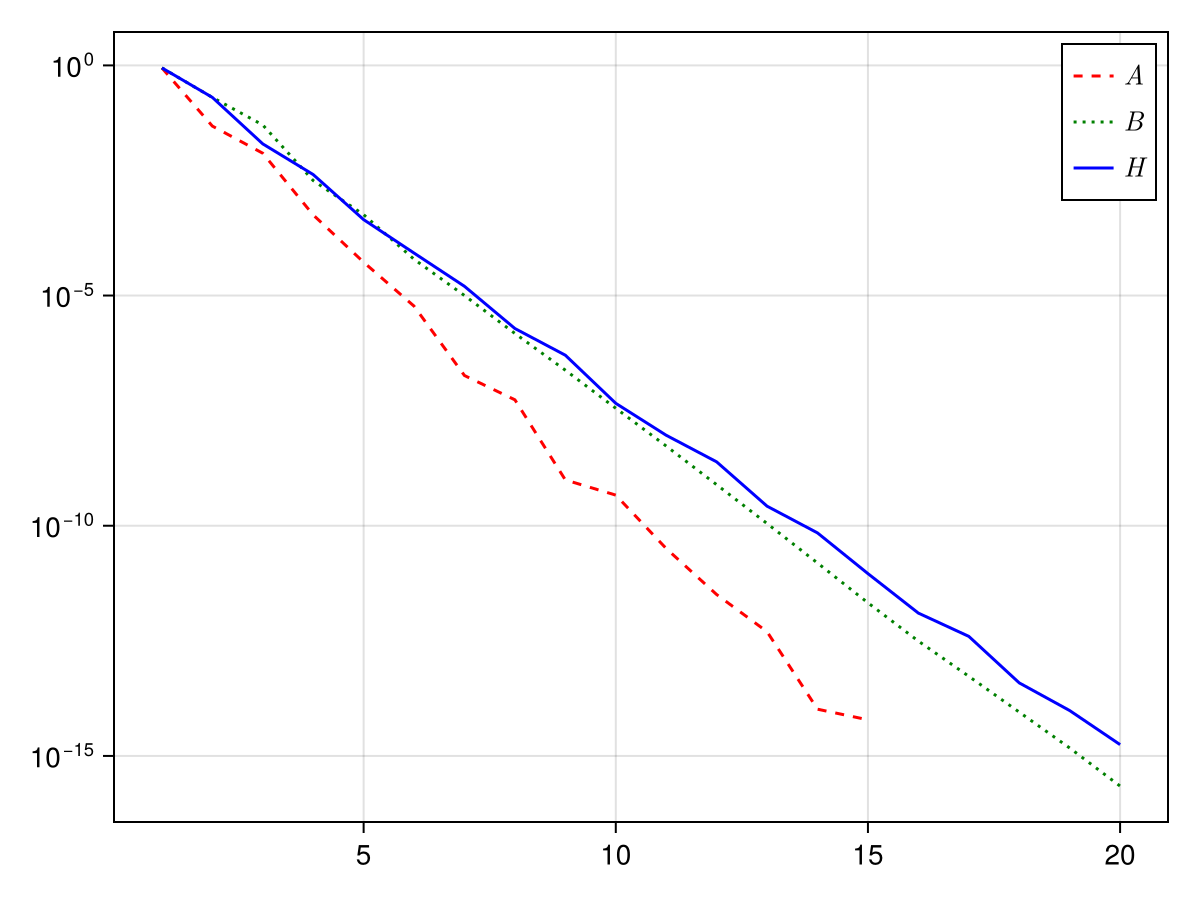

In [10]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_H = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_H, color=:blue, linestyle=:solid, label=L"H")

axislegend(ax)
fig

In [14]:
L₁C_n = (14, 19, 19)

L₁C_lb = SA[0.0, 0.0, Cmed]
L₁C_ub = SA[0.5, 1.0, Cmax]

coefs = generate_coefficients(L₁C, L₁C_n, L₁C_lb, L₁C_ub; tol=tol)

println("L₁ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("C_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₁ coefficients size = (15, 20, 20)
A_coefs_maxend = 7.847179649620265e-15
B_coefs_maxend = 3.005993642455608e-16
C_coefs_maxend = 6.298439762970417e-16


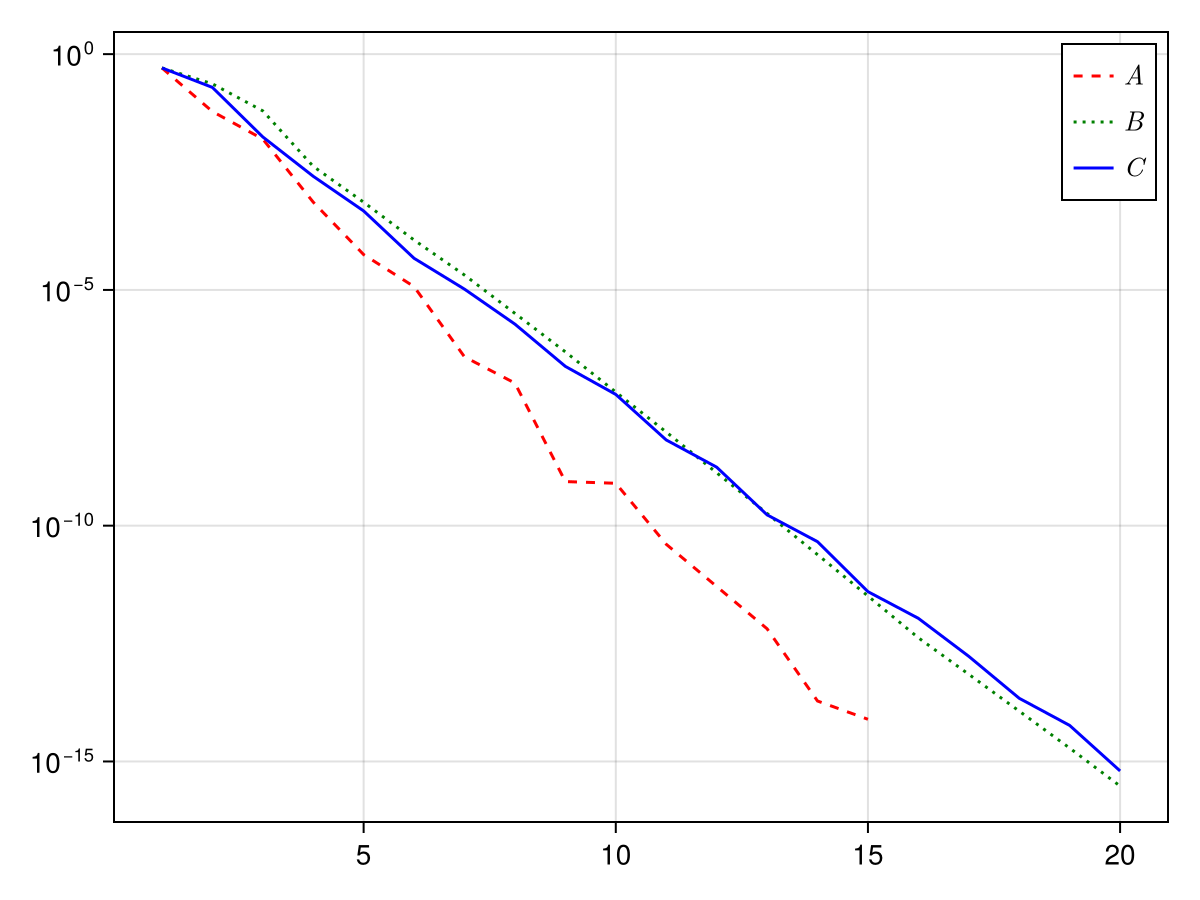

In [15]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)

coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_C = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_C, color=:blue, linestyle=:solid, label=L"C")

axislegend(ax)
fig

In [19]:
L₁C_n = (14, 19, 20)

L₁C_lb = SA[0.0, 0.0, Cmax]
L₁C_ub = SA[0.5, 1.0, Cmax2]

coefs = generate_coefficients(L₁C, L₁C_n, L₁C_lb, L₁C_ub; tol=tol)

println("L₁ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("C_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₁ coefficients size = (15, 20, 21)
A_coefs_maxend = 1.4138045776333545e-14
B_coefs_maxend = 5.034402301890466e-16
C_coefs_maxend = 3.3924408812606286e-16


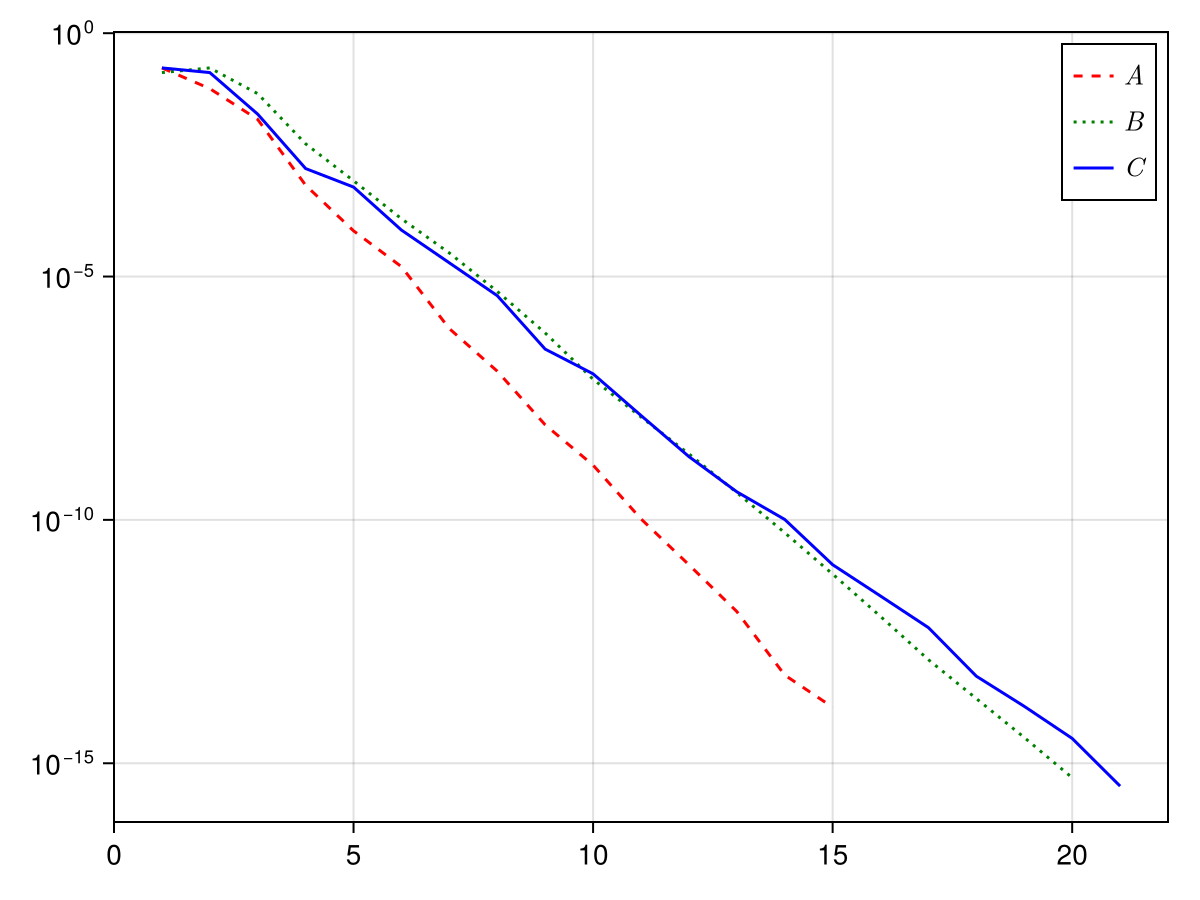

In [20]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)

coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_C = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_C, color=:blue, linestyle=:solid, label=L"C")

axislegend(ax)
fig

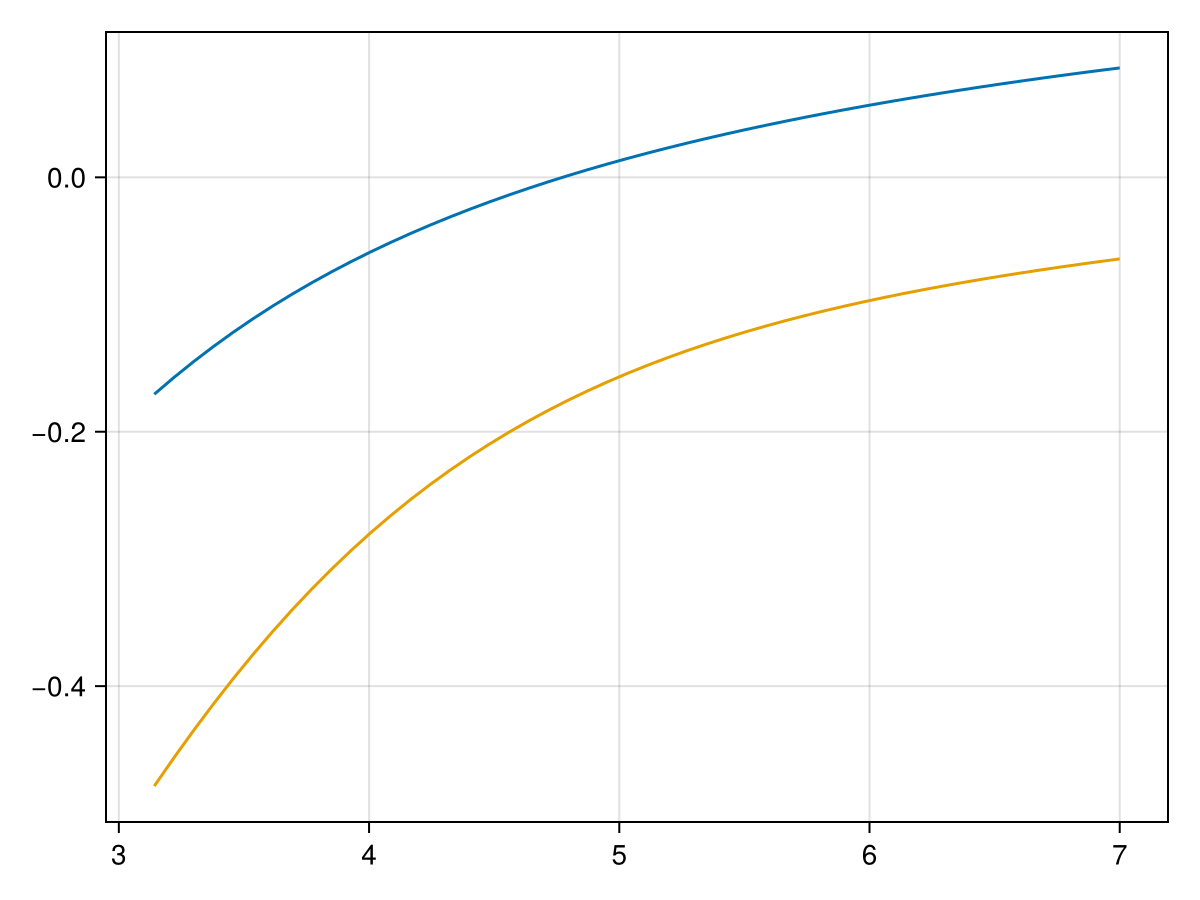

In [50]:
# hvals = collect(LinRange(Hmin, Hmed, 50))
# hvals = collect(LinRange(Hmed, Hmax, 50))
hvals = collect(LinRange(Hmax, Hmax2, 50))

x1 = [[0.0, 0.0, h] for h in hvals]
x2 = [[0.5, 1.0, h] for h in hvals]

l_x1 = L₁H.(x1)
l_x2 = L₁H.(x2)

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, hvals, l_x1)
lines!(ax, hvals, l_x2)
fig

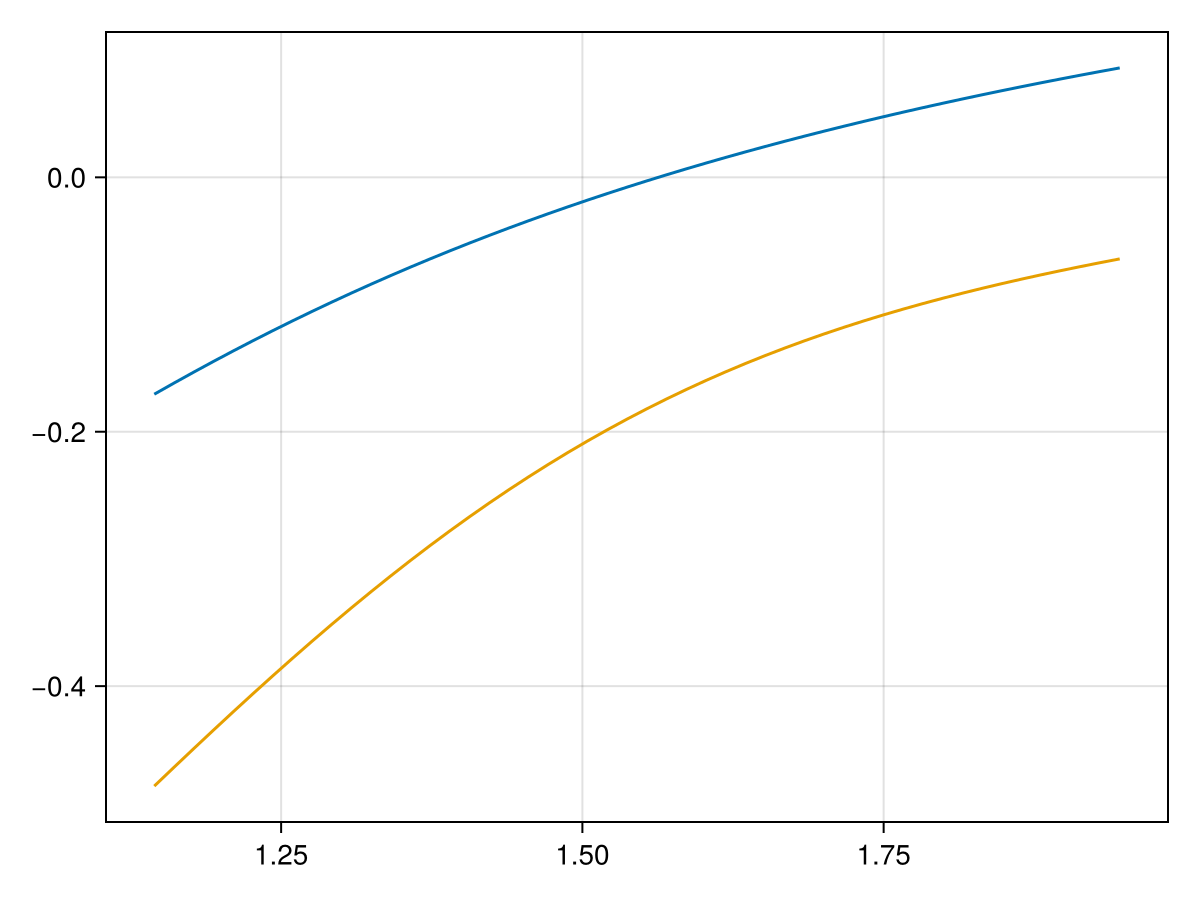

In [51]:
# cvals = collect(LinRange(Cmin, Cmed, 50))
# cvals = collect(LinRange(Cmed, Cmax, 50))
cvals = collect(LinRange(Cmax, Cmax2, 50))

x1 = [[0.0, 0.0, c] for c in cvals]
x2 = [[0.5, 1.0, c] for c in cvals]

l_x1 = L₁C.(x1)
l_x2 = L₁C.(x2)

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, cvals, l_x1)
lines!(ax, cvals, l_x2)
fig

____

In [45]:
Hmed1 = 0.4
Cmed1 = log(Hmed1)

Hmed2 = 1.5
Cmed2 = log(Hmed2);

In [25]:
L₂C_n = (11, 18, 23)

L₂C_lb = SA[0.0, 0.0, Cmin]
L₂C_ub = SA[0.5, 2.0, Cmed1]

coefs = generate_coefficients(L₂C, L₂C_n, L₂C_lb, L₂C_ub; tol=tol)

println("L₂ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("C_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₂ coefficients size = (12, 19, 24)
A_coefs_maxend = 4.478510809935461e-15
B_coefs_maxend = 3.9499188821896005e-15
C_coefs_maxend = 7.539179840124734e-15


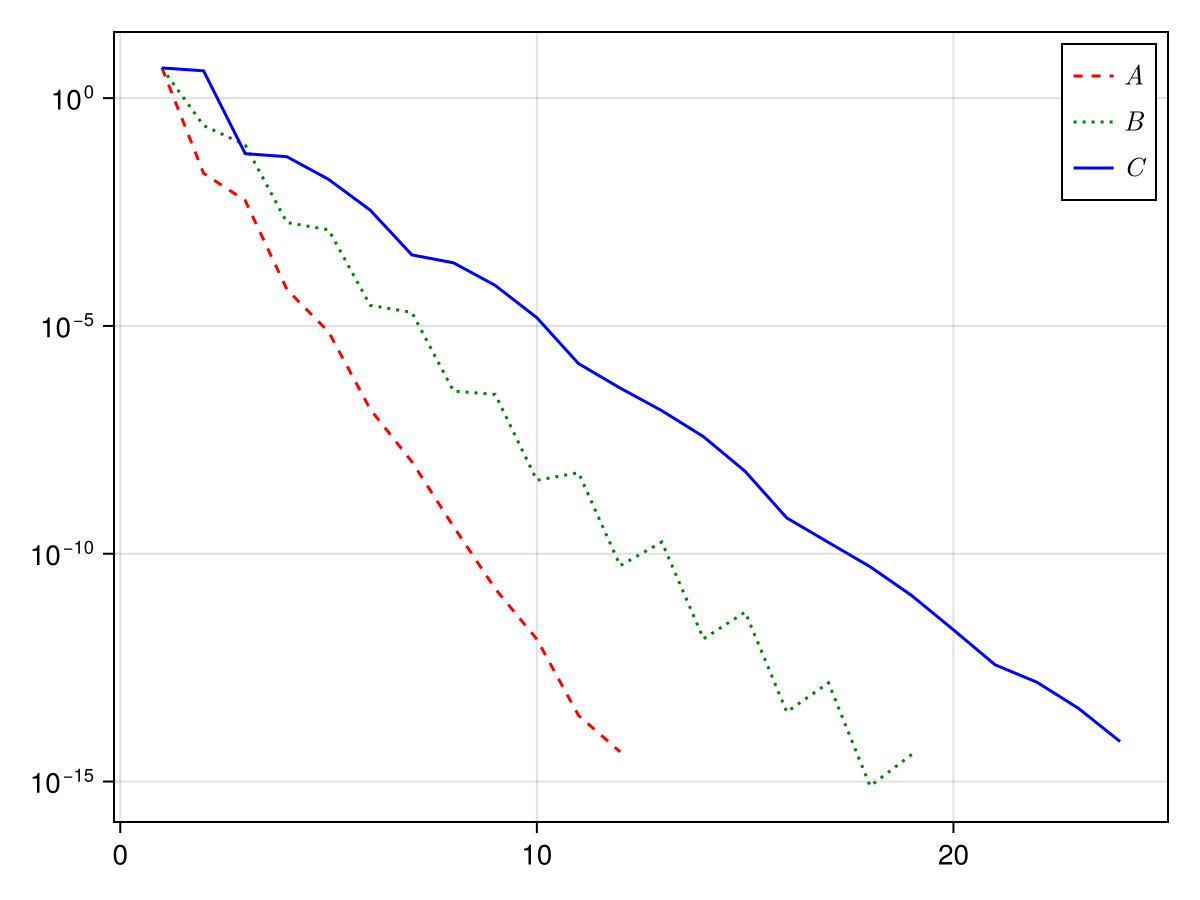

In [26]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_C = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_C, color=:blue, linestyle=:solid, label=L"C")

axislegend(ax)
fig

In [30]:
L₂C_n = (11, 18, 22)

L₂C_lb = SA[0.0, 0.0, Cmed1]
L₂C_ub = SA[0.5, 2.0, Cmed2]

coefs = generate_coefficients(L₂C, L₂C_n, L₂C_lb, L₂C_ub; tol=tol)

println("L₂ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("C_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₂ coefficients size = (12, 19, 23)
A_coefs_maxend = 7.514890194040278e-15
B_coefs_maxend = 5.979848286778952e-15
C_coefs_maxend = 1.3310442432971574e-15


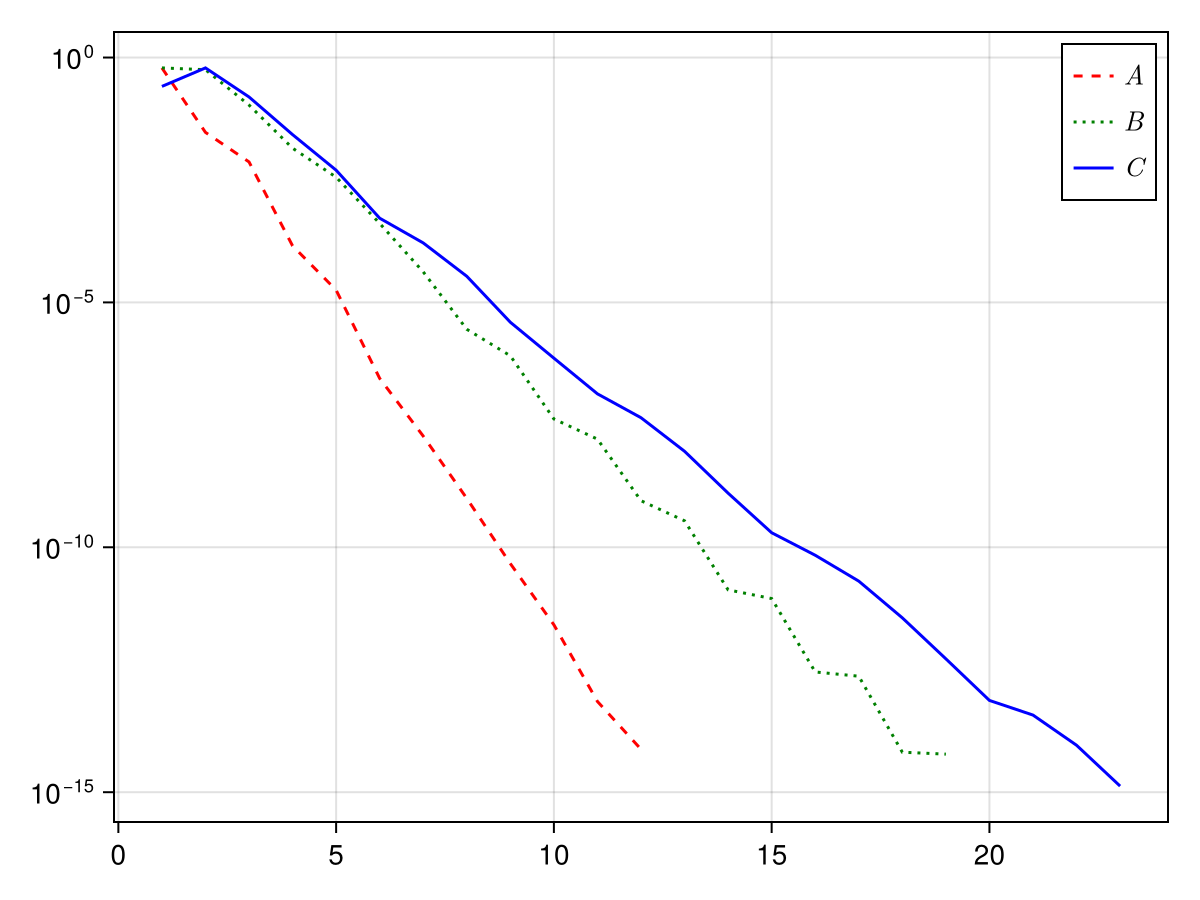

In [31]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_C = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_C, color=:blue, linestyle=:solid, label=L"C")

axislegend(ax)
fig

In [35]:
L₂C_n = (12, 20, 21)

L₂C_lb = SA[0.0, 0.0, Cmed2]
L₂C_ub = SA[0.5, 2.0, Cmax]

coefs = generate_coefficients(L₂C, L₂C_n, L₂C_lb, L₂C_ub; tol=tol)

println("L₂ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("C_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₂ coefficients size = (13, 21, 22)
A_coefs_maxend = 3.137808871121377e-16
B_coefs_maxend = 3.6449293759599663e-16
C_coefs_maxend = 6.597896832058073e-16


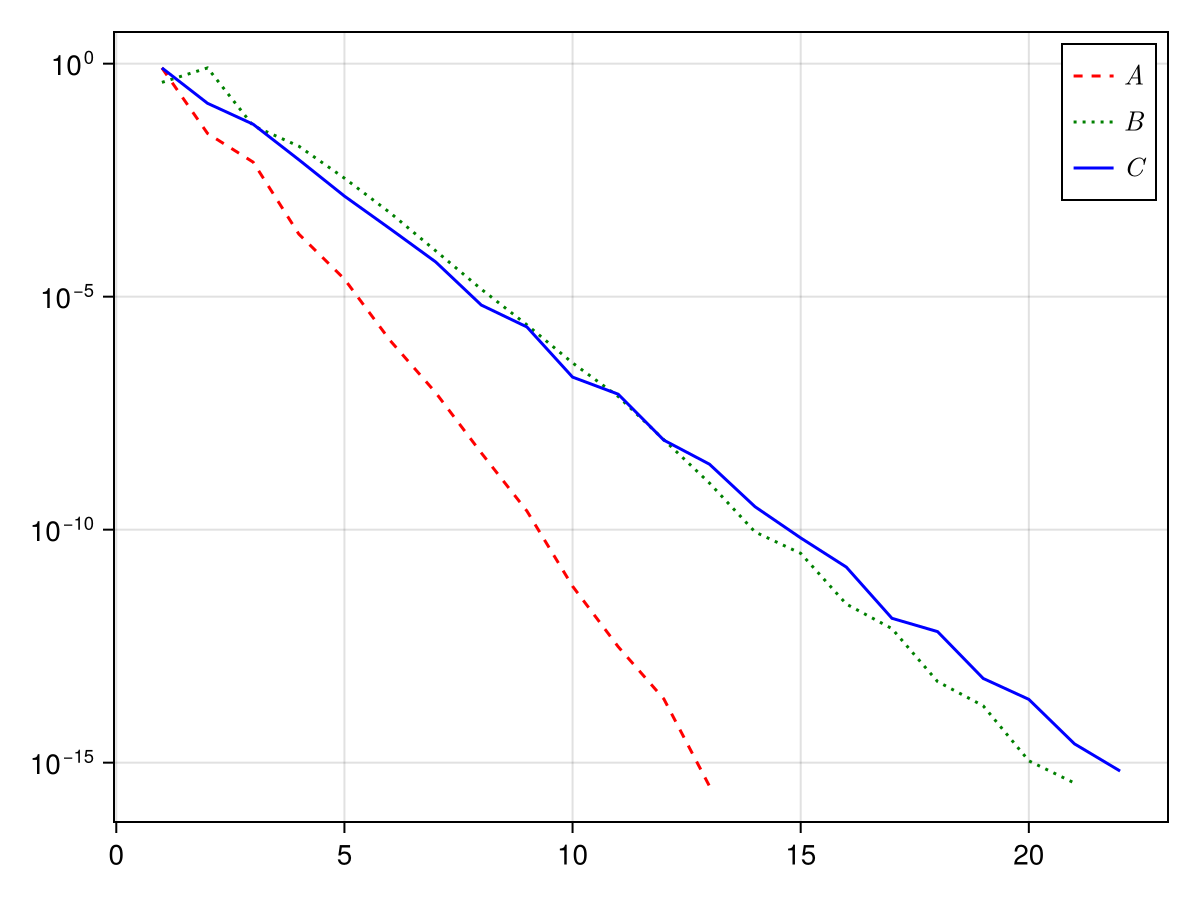

In [36]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_C = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_C, color=:blue, linestyle=:solid, label=L"C")

axislegend(ax)
fig

In [40]:
L₂C_n = (13, 21, 21)

L₂C_lb = SA[0.0, 0.0, Cmax]
L₂C_ub = SA[0.5, 2.0, Cmax2]

coefs = generate_coefficients(L₂C, L₂C_n, L₂C_lb, L₂C_ub; tol=tol)

println("L₂ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("C_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₂ coefficients size = (14, 22, 22)
A_coefs_maxend = 3.4695232636021617e-16
B_coefs_maxend = 3.797404690841045e-16
C_coefs_maxend = 2.478781565533229e-16


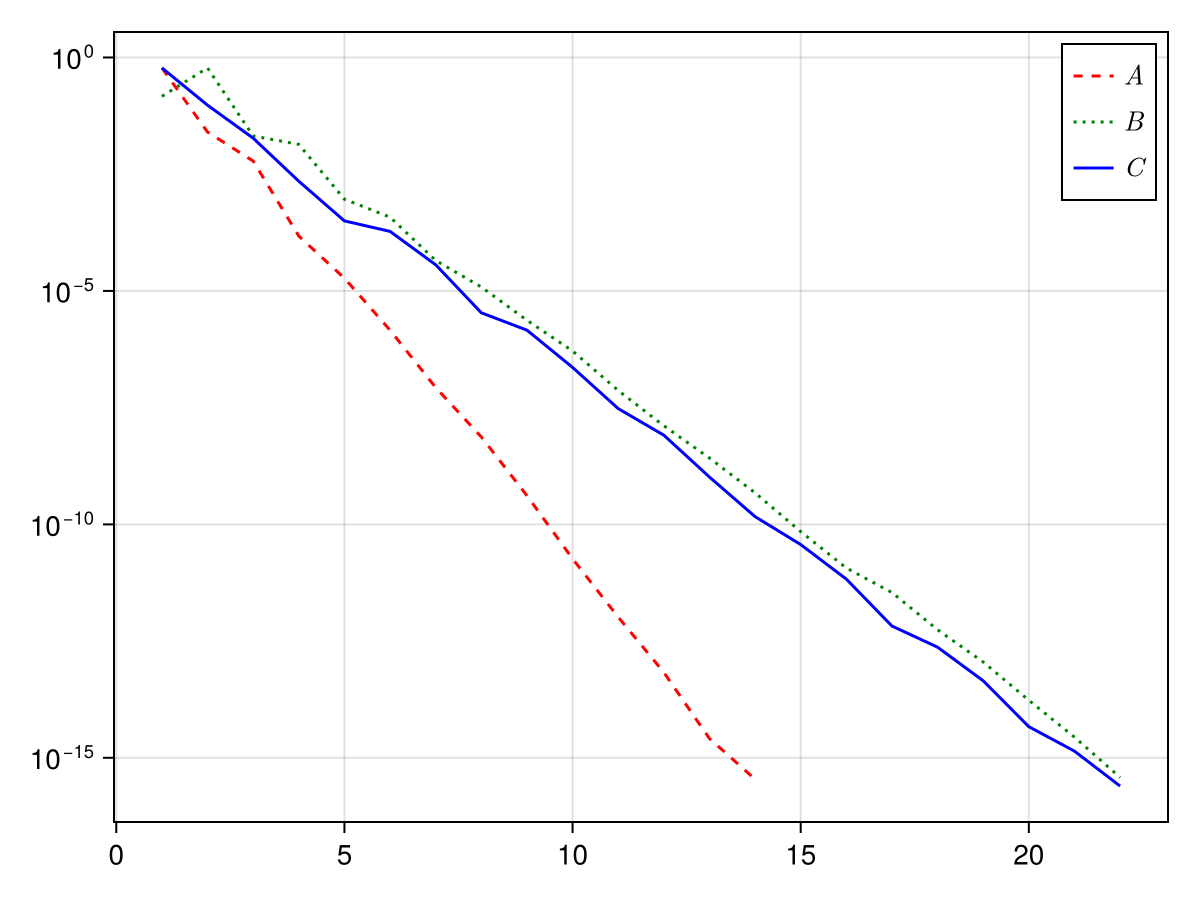

In [41]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_C = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_C, color=:blue, linestyle=:solid, label=L"C")

axislegend(ax)
fig

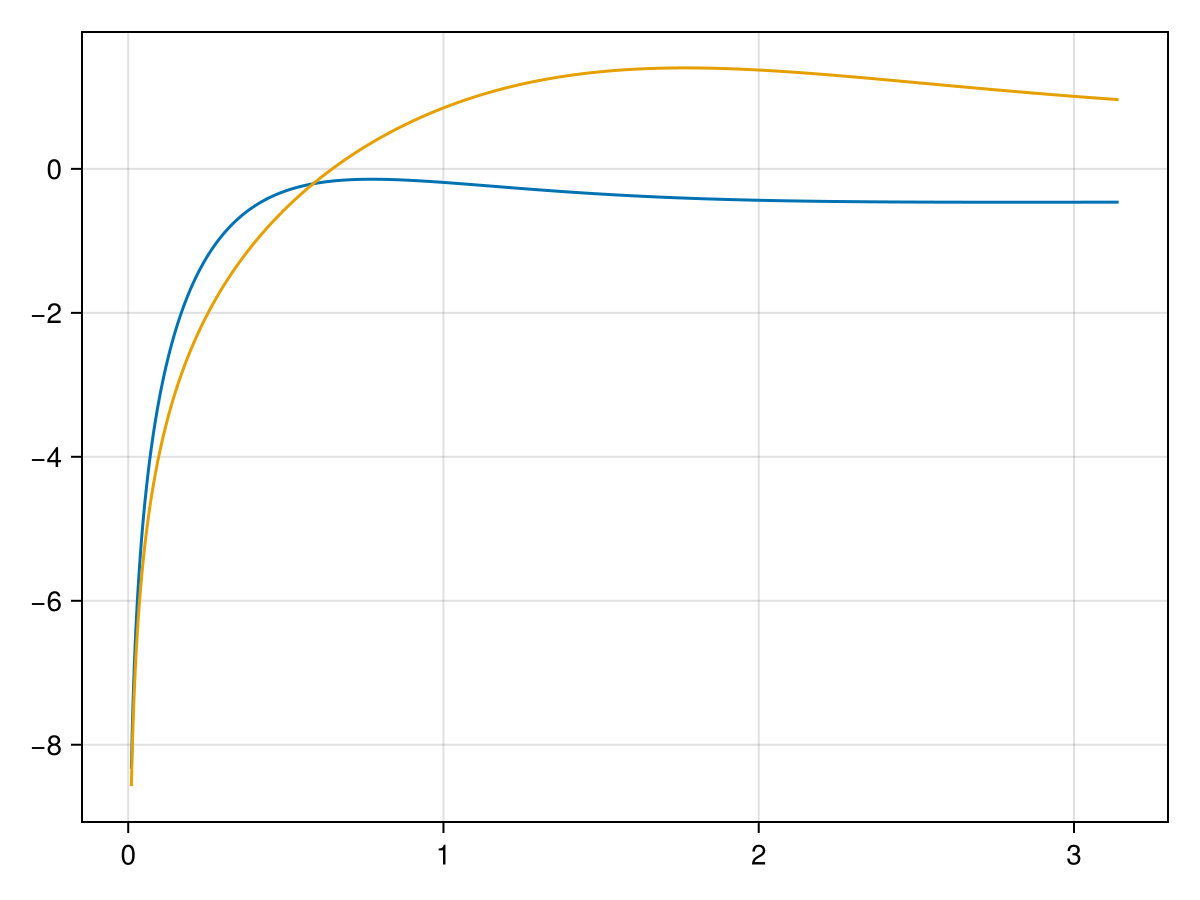

In [75]:
# hvals = collect(LinRange(Hmin, Hmed1, 50))
# hvals = collect(LinRange(Hmed1, Hmed2, 50))
# hvals = collect(LinRange(Hmed2, Hmax, 50))
# hvals = collect(LinRange(Hmax, Hmax2, 50))
hvals = collect(LinRange(Hmin, Hmax, 1000))

x1 = [[0.0, 0.0, h] for h in hvals]
x2 = [[0.5, 2.0, h] for h in hvals]

l_x1 = L₂H.(x1)
l_x2 = L₂H.(x2)

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, hvals, l_x1)
lines!(ax, hvals, l_x2)

# save("lhplot.svg", fig)

fig

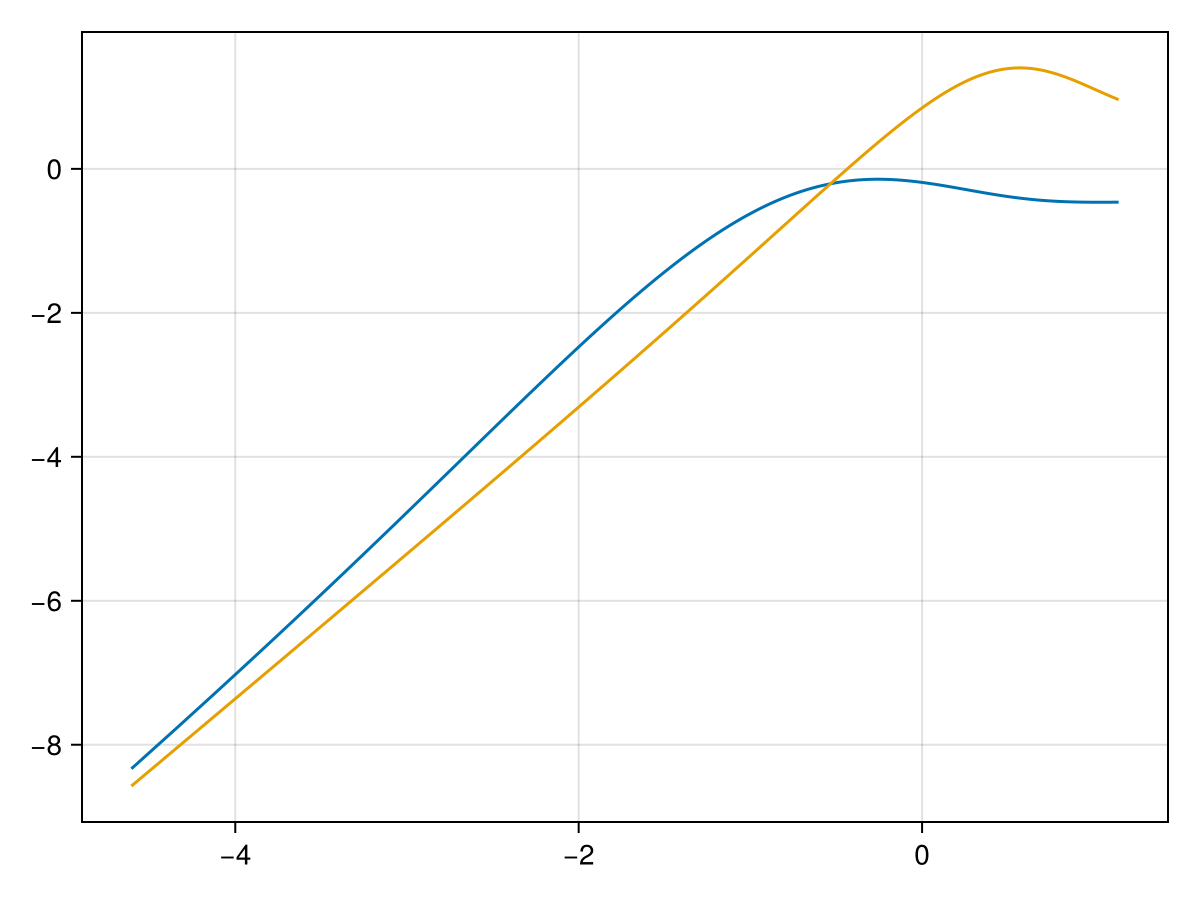

In [76]:
dvals = log.(hvals)

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, dvals, l_x1)
lines!(ax, dvals, l_x2)
fig

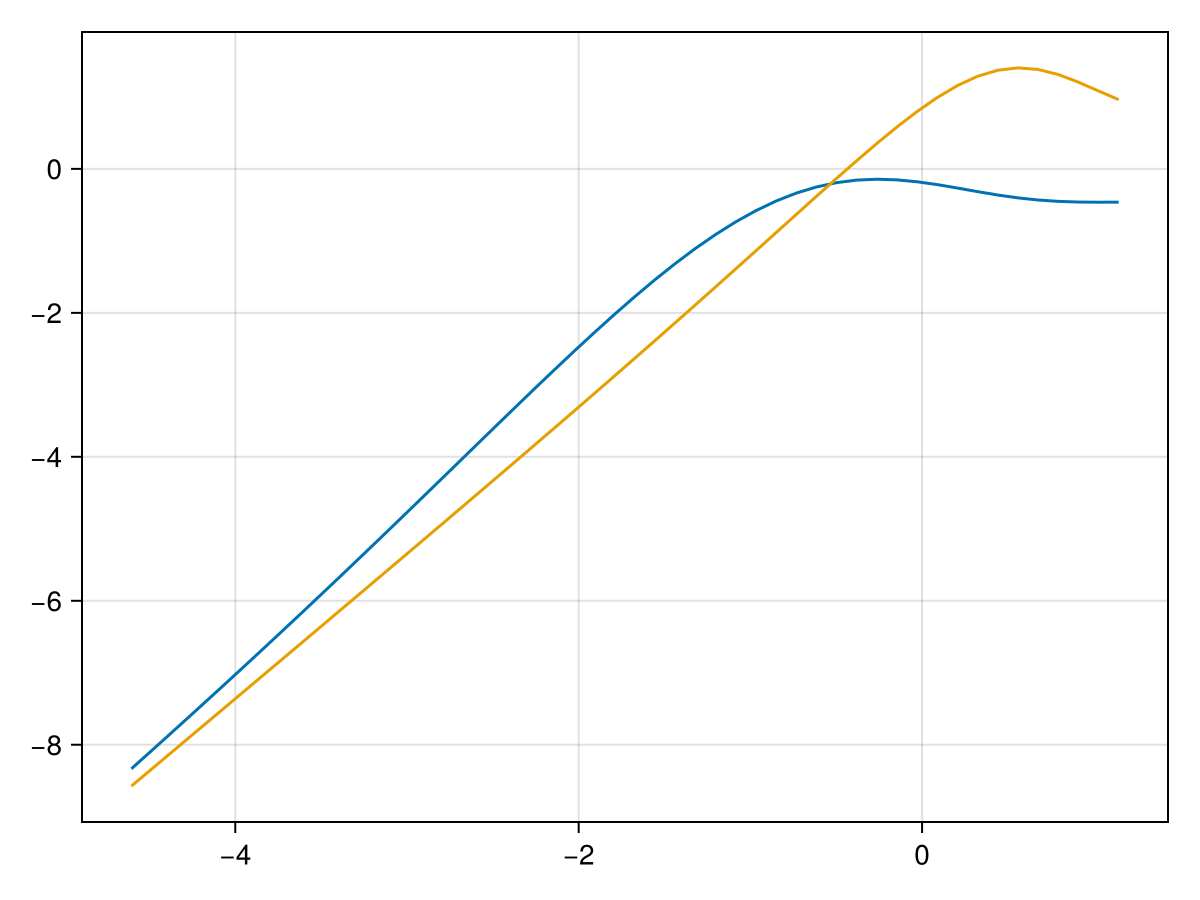

In [82]:
# cvals = collect(LinRange(Cmin, Cmed1, 50))
# cvals = collect(LinRange(Cmed1, Cmed2, 50))
# cvals = collect(LinRange(Cmed2, Cmax, 50))
# cvals = collect(LinRange(Cmax, Cmax2, 50))
cvals = collect(LinRange(Cmin, Cmax, 50))

x1 = [[0.0, 0.0, c] for c in cvals]
x2 = [[0.5, 2.0, c] for c in cvals]

l_x1 = L₂C.(x1)
l_x2 = L₂C.(x2)

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, cvals, l_x1)
lines!(ax, cvals, l_x2)
fig

In [ ]:
α = 2.0
β = 0.0
γ = 1.0

function L₂D(x::AbstractVector{<:Real})
    A, B, D = x
    x̄ = [A, B, exp(α*A + β*B + γ*A*B + D)]
    return L₂H(x̄)
end

Amin, Amed, Amax = 0.0, 0.25, 0.5
Bmin, Bmed, Bmax = 0.0, 1.0, 2.0
Hmin, Hmed, Hmax = 1e-2, 1.0, π

# H = exp(sqrt(D))
Dmin = log(Hmin) - α*Amin - β*Bmin - γ*Amin*Bmin
Dmed = log(Hmed) - α*Amed - β*Bmed - γ*Amed*Bmed
Dmax = log(Hmax) - α*Amax - β*Bmax - γ*Amax*Bmax

dvals = collect(LinRange(Dmin, Dmax, 50))

x1 = [[Amin, Bmin, d] for d in dvals]
x2 = [[Amed, Bmed, d] for d in dvals]
x3 = [[Amax, Bmax, d] for d in dvals]

l_x1 = L₂D.(x1);
l_x2 = L₂D.(x2);
l_x3 = L₂D.(x3);

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, dvals, l_x1)
lines!(ax, dvals, l_x2)
lines!(ax, dvals, l_x3)
fig

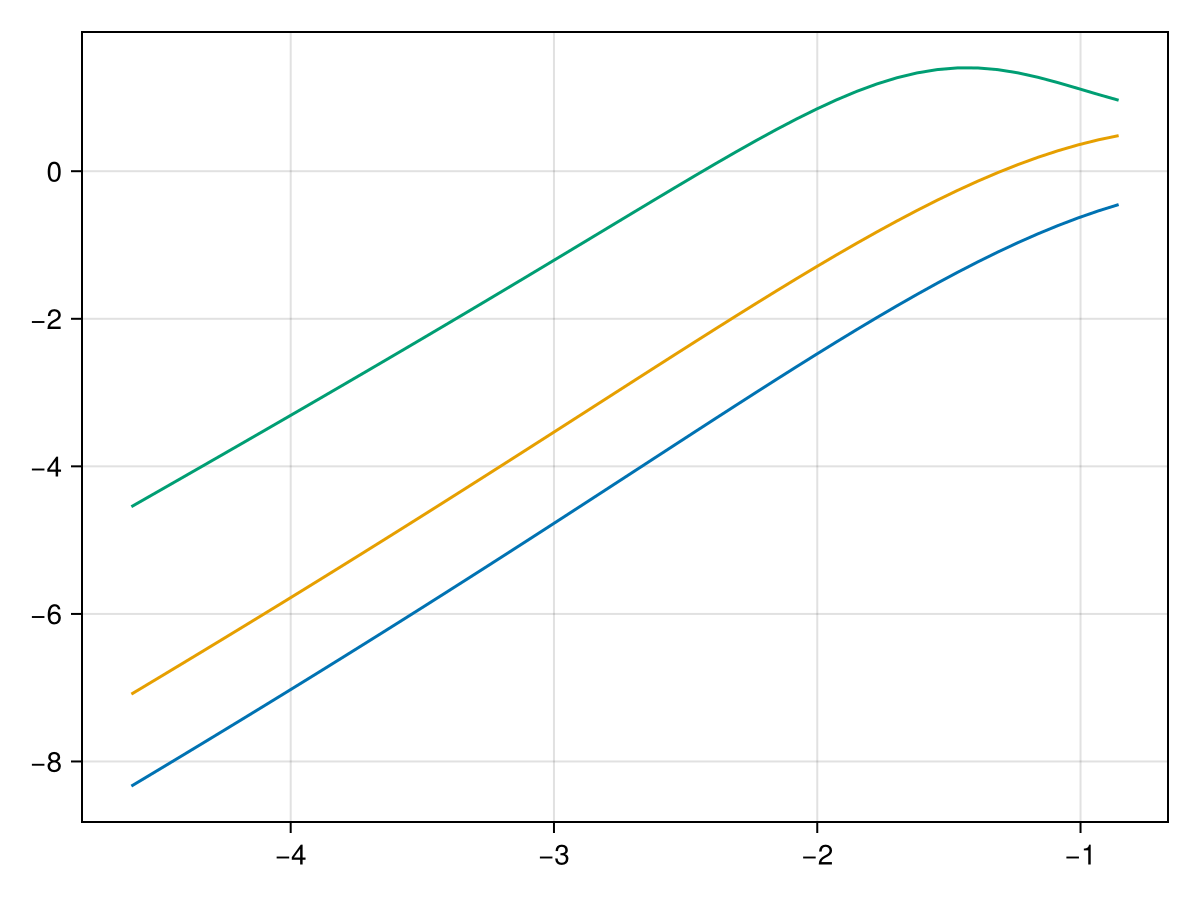

In [130]:
α = 2.0
β = 0.0
γ = 1.0

function L₂D(x::AbstractVector{<:Real})
    A, B, D = x
    x̄ = [A, B, exp(α*A + β*B + γ*A*B + D)]
    return L₂H(x̄)
end

Amin, Amed, Amax = 0.0, 0.25, 0.5
Bmin, Bmed, Bmax = 0.0, 1.0, 2.0
Hmin, Hmed, Hmax = 1e-2, 1.0, π

# H = exp(α*A + β*B + γ*A*B + D)
Dmin = log(Hmin) - α*Amin - β*Bmin - γ*Amin*Bmin
Dmed = log(Hmed) - α*Amed - β*Bmed - γ*Amed*Bmed
Dmax = log(Hmax) - α*Amax - β*Bmax - γ*Amax*Bmax

dvals = collect(LinRange(Dmin, Dmax, 50))

x1 = [[Amin, Bmin, d] for d in dvals]
x2 = [[Amed, Bmed, d] for d in dvals]
x3 = [[Amax, Bmax, d] for d in dvals]

l_x1 = L₂D.(x1);
l_x2 = L₂D.(x2);
l_x3 = L₂D.(x3);

fig = Figure()
ax = Axis(fig[1, 1])
lines!(ax, dvals, l_x1)
lines!(ax, dvals, l_x2)
lines!(ax, dvals, l_x3)
fig

In [131]:
Dmed = log(Hmed) - α*Amax - β*Bmax - γ*Amax*Bmax

L₂D_n = (30, 30, 30)

L₂D_lb = SA[Amin, Bmin, Dmin]
L₂D_ub = SA[Amax, Bmax, Dmed]

coefs = generate_coefficients(L₂D, L₂D_n, L₂D_lb, L₂D_ub; tol=tol)

println("L₂ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("D_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₂ coefficients size = (23, 19, 25)
A_coefs_maxend = 1.1048625010564493e-15
B_coefs_maxend = 5.104961351405492e-15
D_coefs_maxend = 1.966854815268831e-15


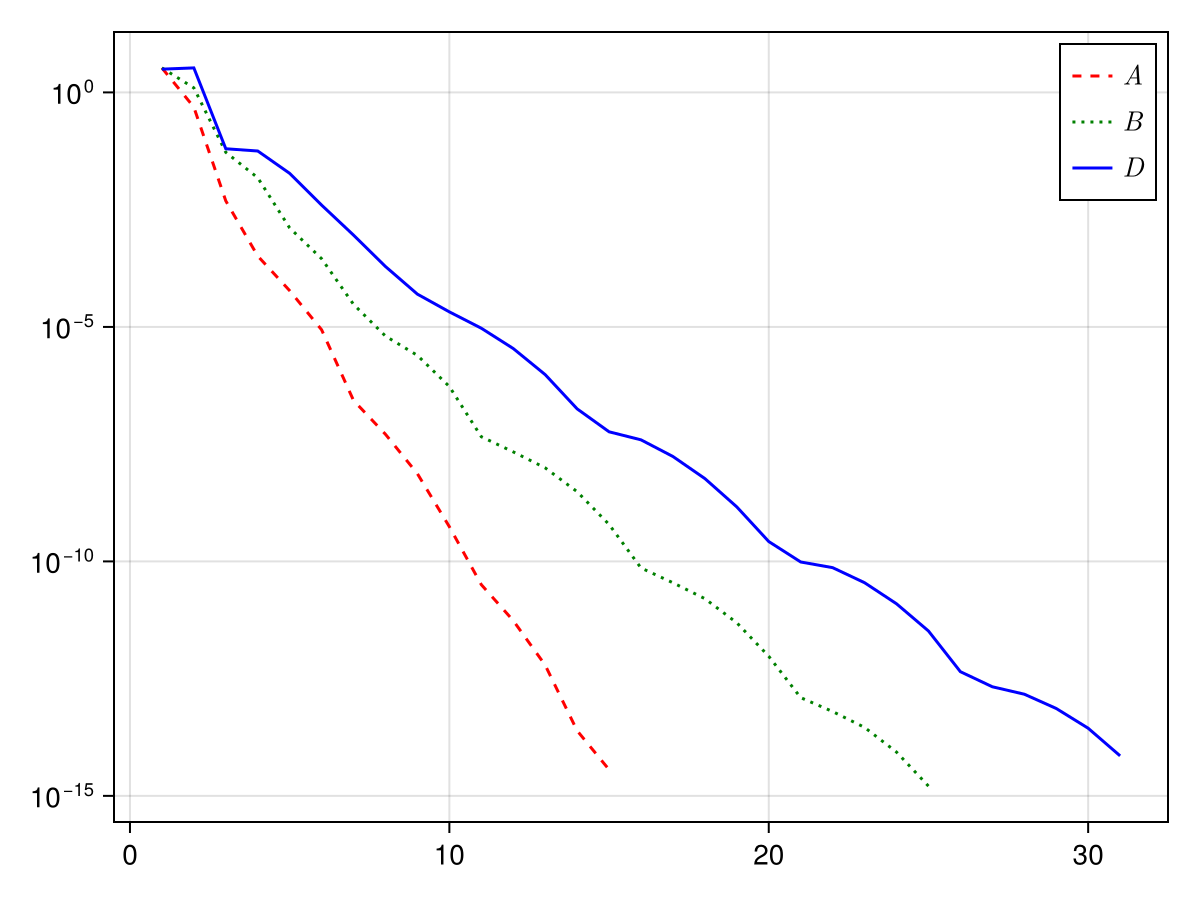

In [111]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_D = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_D, color=:blue, linestyle=:solid, label=L"D")

axislegend(ax)
fig

In [132]:
L₂D_n = (30, 30, 30)

L₂D_lb = SA[Amin, Bmin, Dmed]
L₂D_ub = SA[Amax, Bmax, Dmax]

coefs = generate_coefficients(L₂D, L₂D_n, L₂D_lb, L₂D_ub; tol=tol)

println("L₂ coefficients size = ", coefs.size)
println("A_coefs_maxend = ", maximum(abs.(coefs[end, :, :])))
println("B_coefs_maxend = ", maximum(abs.(coefs[:, end, :])))
println("D_coefs_maxend = ", maximum(abs.(coefs[:, :, end])))

L₂ coefficients size = (31, 24, 26)
A_coefs_maxend = 2.1272223087345356e-14
B_coefs_maxend = 2.500504622970261e-16
D_coefs_maxend = 5.370030471608173e-16


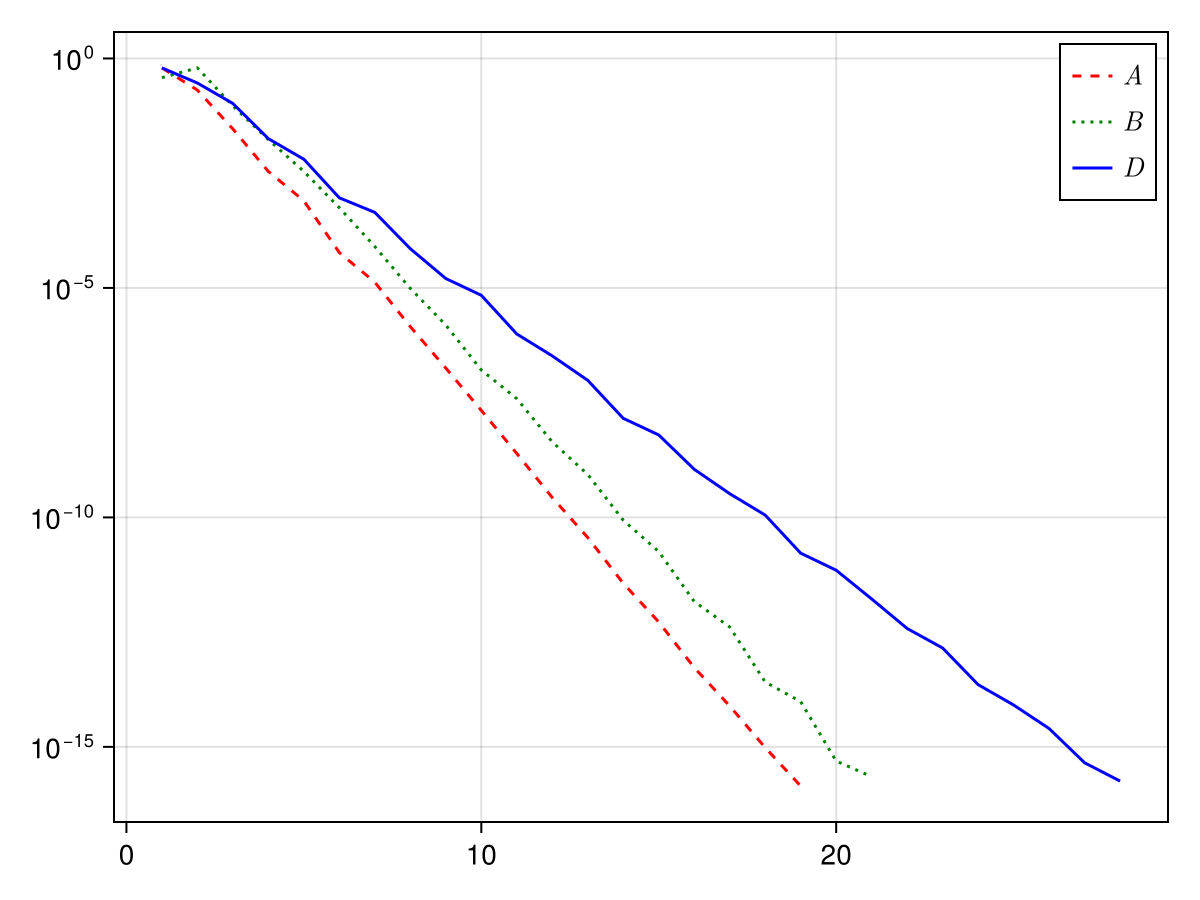

In [106]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10)
    
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_D = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)]

lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label=L"A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label=L"B")
lines!(ax, 1:size(coefs, 3), coefs_D, color=:blue, linestyle=:solid, label=L"D")

axislegend(ax)
fig